# Aviation Emissions: Cleaning & EDA

European aviation pollutant data (CO₂, NOx, SOx) by state, segment, and flight phase (2019–2024). Source: EUROCONTROL.

## 1. Setup

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [41]:
BLUE   = "#2176AE"
ORANGE = "#E76F51"
TEAL   = "#2A9D8F"
SLATE  = "#264653"
RED    = "#E63946"
GRAY   = "#C8C8C8"
YELLOW = "#E9C46A"

plt.rcParams.update({
    "figure.dpi":          130,
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           False,
    "font.family":         "sans-serif",
    "axes.titlesize":      12,
    "axes.titleweight":    "bold",
    "axes.labelsize":      10,
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "legend.fontsize":     9,
    "legend.frameon":      False,
    "figure.titlesize":    13,
    "figure.titleweight":  "bold",
})

## 2. Data Loading & Cleaning

In [42]:
df = pd.read_csv("data/g2g_emissions.csv")
print(f"Shape: {df.shape}")
display(df.info())
display(df.sample(5))

Shape: (511627, 12)
<class 'pandas.DataFrame'>
RangeIndex: 511627 entries, 0 to 511626
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LEVEL           511627 non-null  str    
 1   AREA            511627 non-null  str    
 2   FOCUS_TYPE      511627 non-null  str    
 3   YEAR            511627 non-null  int64  
 4   MONTH           511627 non-null  int64  
 5   MARKET_SEGMENT  511627 non-null  str    
 6   FLIGHT_TYPE     511627 non-null  str    
 7   FLIGHT_PHASE    511627 non-null  str    
 8   NB_FLIGHTS      511627 non-null  int64  
 9   CO2_TONS        511627 non-null  float64
 10  NOX_KG          511627 non-null  float64
 11  SOX_KG          511627 non-null  float64
dtypes: float64(3), int64(3), str(6)
memory usage: 46.8 MB


None

,LEVEL,AREA,FOCUS_TYPE,YEAR,MONTH,MARKET_SEGMENT,FLIGHT_TYPE,FLIGHT_PHASE,NB_FLIGHTS,CO2_TONS,NOX_KG,SOX_KG
363363,STATE,RS,AREA FOCUS,2021,2,business,O,cruise,1058,730.7,2120.94,193.53
130240,STATE,BG,AREA FOCUS,2021,1,regional,I,taxi-out,86,15.3,4.33,4.18
279983,STATE,RO,AREA FOCUS,2024,11,lowcost,I,descent,277,182.0,575.99,48.52
330710,STATE,PL,AREA FOCUS,2020,3,lowcost,I,descent,117,155.2,498.96,41.29
385521,STATE,PT - Santa Maria FIR,AREA FOCUS,2021,9,lowcost,D,taxi-out,158,29.6,41.37,7.94


In [43]:
df = df.drop(columns=["FOCUS_TYPE"])

df["CO2_KG"] = df["CO2_TONS"] * 1000
df = df.drop(columns=["CO2_TONS"])

df["DATE"] = pd.to_datetime(
    df["YEAR"].astype(str) + "-" + df["MONTH"].astype(str).str.zfill(2) + "-01"
)

display(df.describe().round())

,YEAR,MONTH,NB_FLIGHTS,NOX_KG,SOX_KG,CO2_KG,DATE
count,511627.0,511627.0,511627.0,511627.0,511627.0,5.116270e+05,511627
mean,2022.0,7.0,5508.0,67884.0,3637.0,1.364362e+07,2021-12-24 08:48:13.414147
min,2019.0,1.0,1.0,0.0,0.0,0.000000e+00,2019-01-01 00:00:00
25%,2020.0,4.0,148.0,23.0,4.0,1.440000e+04,2020-07-01 00:00:00
50%,2022.0,7.0,689.0,293.0,37.0,1.404000e+05,2022-01-01 00:00:00
75%,2023.0,10.0,3318.0,3921.0,346.0,1.298550e+06,2023-07-01 00:00:00
max,2024.0,12.0,349929.0,23166244.0,1302544.0,4.885929e+09,2024-12-01 00:00:00
std,2.0,3.0,18401.0,611006.0,31395.0,1.177521e+08,NaN


In [44]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates()
print(f"Final shape after deduplication: {df.shape}")

Duplicate rows found: 228003
Final shape after deduplication: (283624, 12)


In [45]:
df_state = df[df["LEVEL"] == "STATE"].copy()
df_net   = df[df["LEVEL"] == "NETWORK"].copy()

df_state.to_csv("data/clean/emission_state_clean.csv", index=False)
df_net.to_csv("data/clean/emission_network_clean.csv", index=False)
print(f"STATE rows: {len(df_state):,}  |  NETWORK rows: {len(df_net):,}")
print("Saved  →  data/clean/emission_state_clean.csv")
print("Saved  →  data/clean/emission_network_clean.csv")

STATE rows: 228,003  |  NETWORK rows: 55,621
Saved  →  data/clean/emission_state_clean.csv
Saved  →  data/clean/emission_network_clean.csv


## 3. Exploratory Data Analysis

In [46]:
CODE2NAME = {
    "AL": "Albania",     "AM": "Armenia",     "AT": "Austria",      "AZ": "Azerbaijan",
    "BA": "Bosnia",      "BE": "Belgium",      "BG": "Bulgaria",     "CH": "Switzerland",
    "CY": "Cyprus",      "CZ": "Czechia",      "DE": "Germany",      "DK": "Denmark",
    "EE": "Estonia",     "ES": "Spain",        "FI": "Finland",      "FR": "France",
    "GB": "UK",          "GE": "Georgia",      "GR": "Greece",       "HR": "Croatia",
    "HU": "Hungary",     "IE": "Ireland",      "IL": "Israel",       "IS": "Iceland",
    "IT": "Italy",       "LT": "Lithuania",    "LU": "Luxembourg",   "LV": "Latvia",
    "MA": "Morocco",     "MD": "Moldova",      "ME": "Montenegro",   "MK": "N.Macedonia",
    "MT": "Malta",       "NL": "Netherlands",  "NO": "Norway",       "PL": "Poland",
    "PT - Lisbon FIR":   "Portugal",
    "PT - Santa Maria FIR": "PT Azores",
    "RO": "Romania",     "RS": "Serbia",       "SE": "Sweden",       "SI": "Slovenia",
    "SK": "Slovakia",    "TR": "Turkey",       "UA": "Ukraine",
}

### 3.1 ECAC Total Emissions Over Time

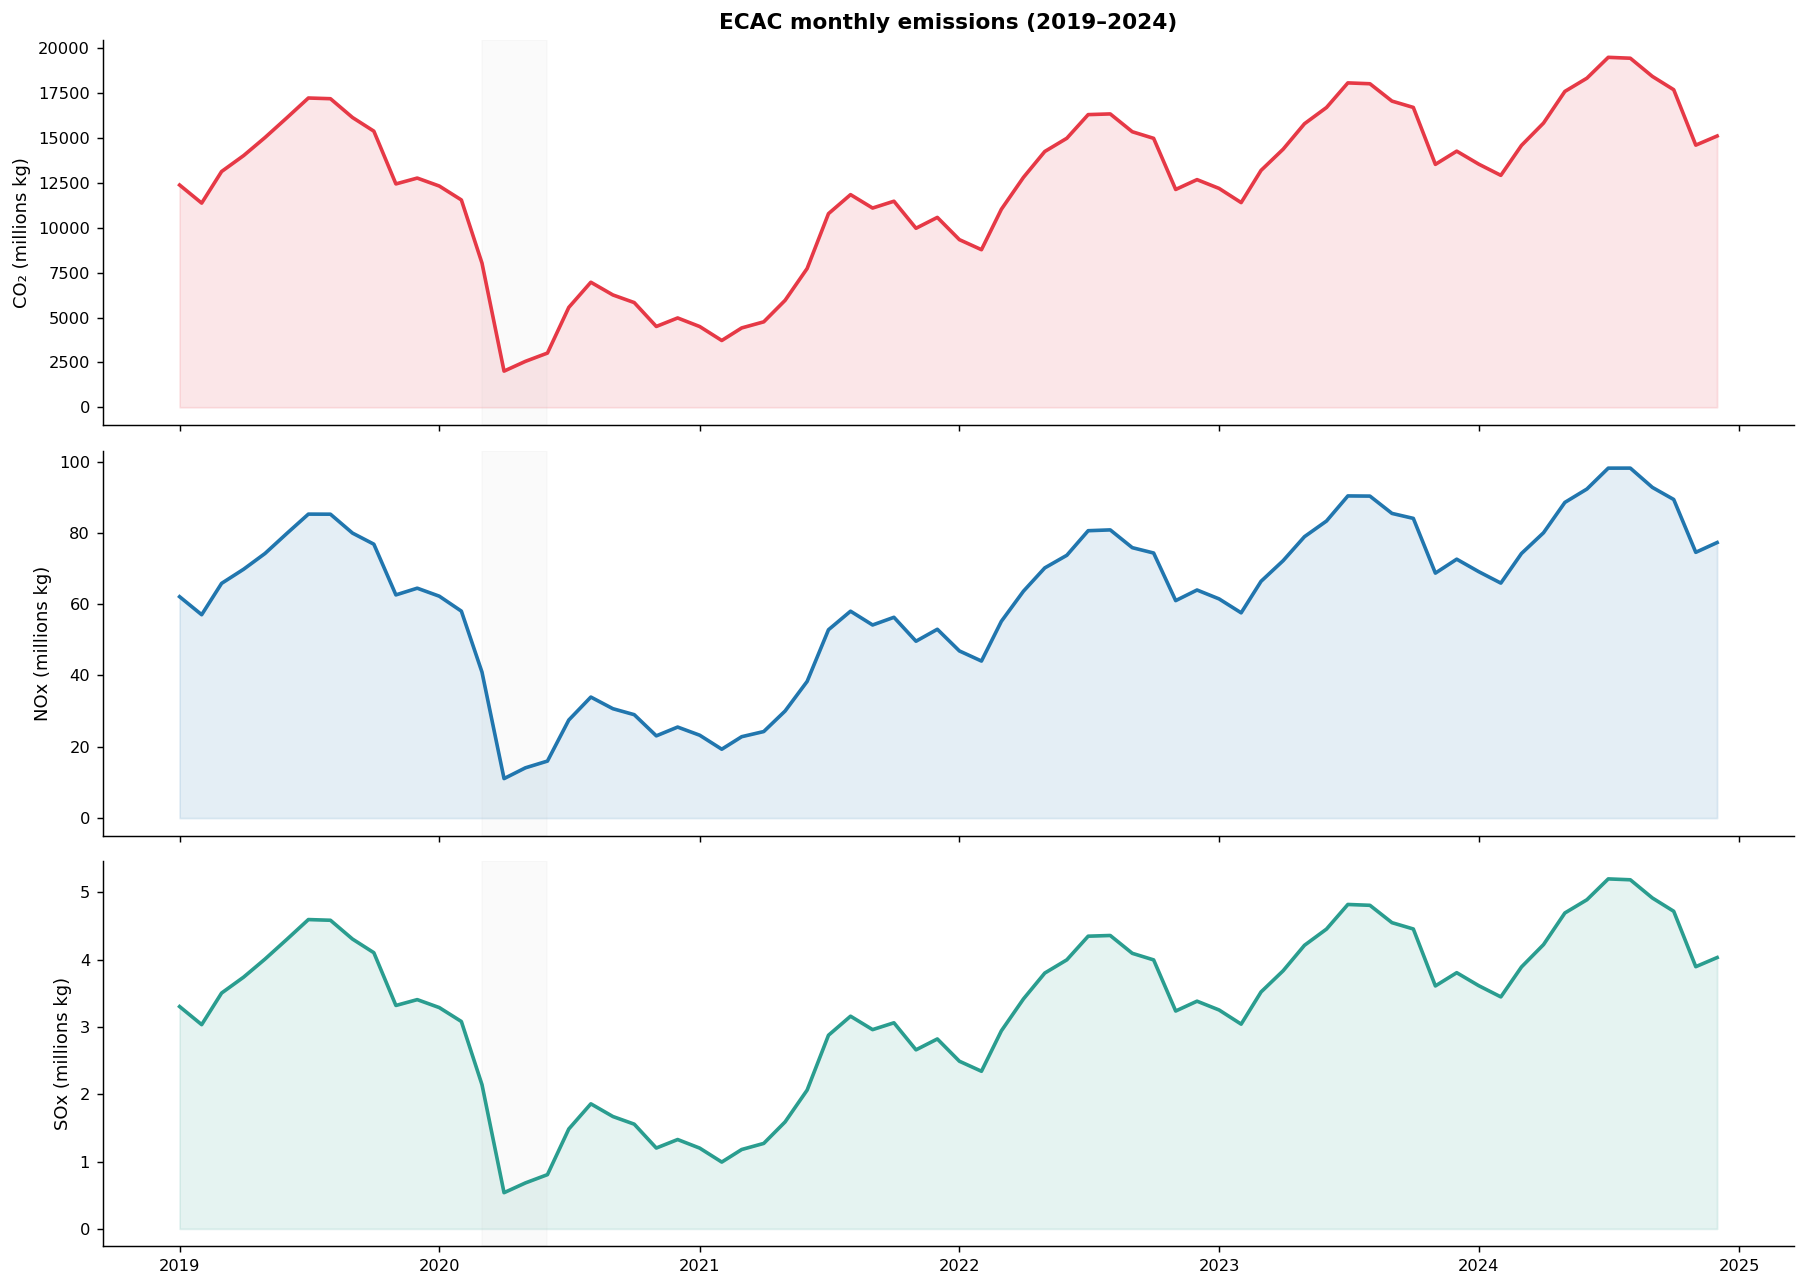

In [47]:
ecac = df_net[df_net["AREA"] == "ECAC"].copy()
ecac_monthly = (
    ecac.groupby("DATE")[["NB_FLIGHTS", "CO2_KG", "NOX_KG", "SOX_KG"]]
    .sum()
    .reset_index()
    .sort_values("DATE")
)

pollutants = [
    ("CO2_KG", "CO\u2082 (millions kg)", RED),
    ("NOX_KG", "NOx (millions kg)",      BLUE),
    ("SOX_KG", "SOx (millions kg)",      TEAL),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (col, label, color) in zip(axes, pollutants):
    ax.fill_between(ecac_monthly["DATE"], ecac_monthly[col] / 1e6,
                    alpha=0.12, color=color)
    ax.plot(ecac_monthly["DATE"], ecac_monthly[col] / 1e6, color=color, lw=2)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"),
               alpha=0.08, color=GRAY)
    ax.set_ylabel(label)

axes[0].set_title("ECAC monthly emissions (2019\u20132024)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

### 3.2 CO\u2082 Seasonality by Year

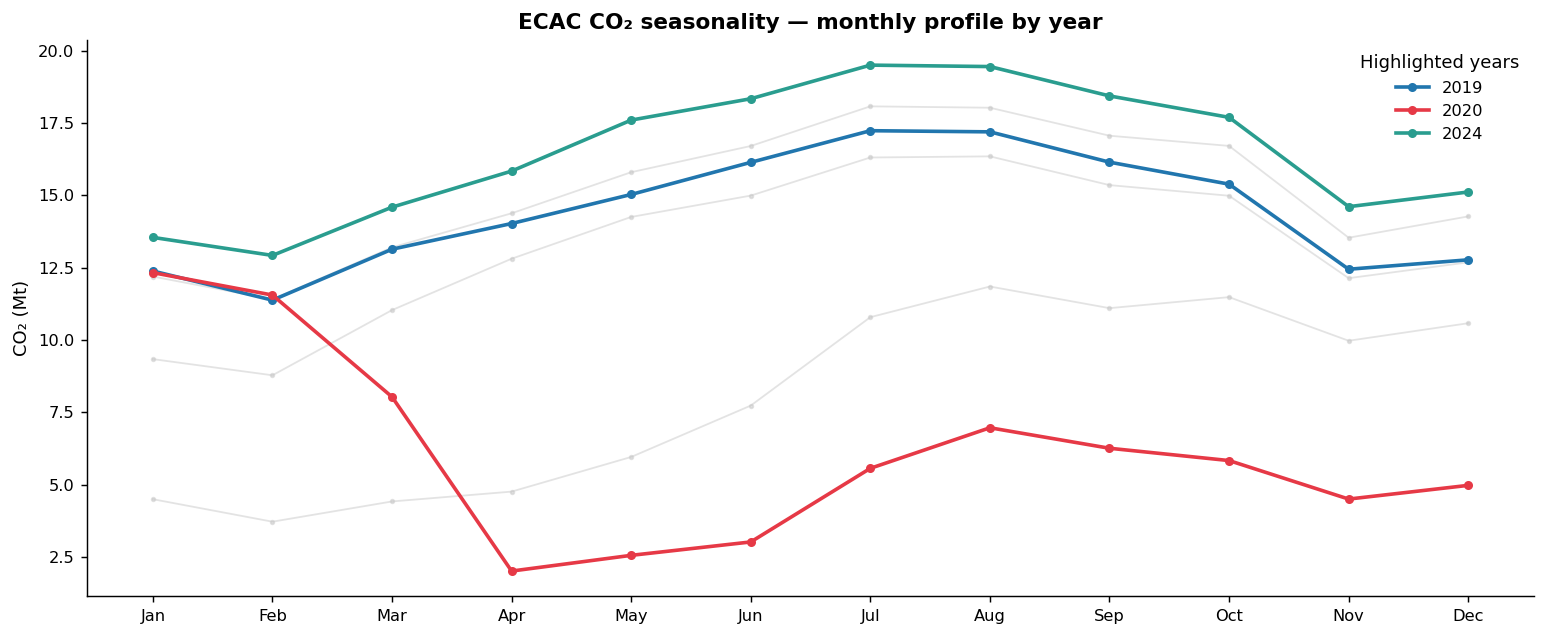

In [48]:
ecac_season = ecac.groupby(["YEAR", "MONTH"])["CO2_KG"].sum().reset_index()
piv_season  = ecac_season.pivot(index="MONTH", columns="YEAR", values="CO2_KG")

HIGHLIGHT  = {2019: BLUE, 2020: RED, 2024: TEAL}
MON_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
for yr in piv_season.columns:
    if yr in HIGHLIGHT:
        ax.plot(piv_season.index, piv_season[yr] / 1e9, marker="o", ms=4,
                color=HIGHLIGHT[yr], lw=2.0, label=str(yr), zorder=3)
    else:
        ax.plot(piv_season.index, piv_season[yr] / 1e9, marker="o", ms=2,
                color=GRAY, lw=1.0, alpha=0.5, label="_nolegend_", zorder=1)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MON_LABELS)
ax.set_ylabel("CO\u2082 (Mt)")
ax.set_title("ECAC CO\u2082 seasonality \u2014 monthly profile by year")
ax.legend(title="Highlighted years")
plt.tight_layout()
plt.show()

### 3.3 CO\u2082 by Market Segment

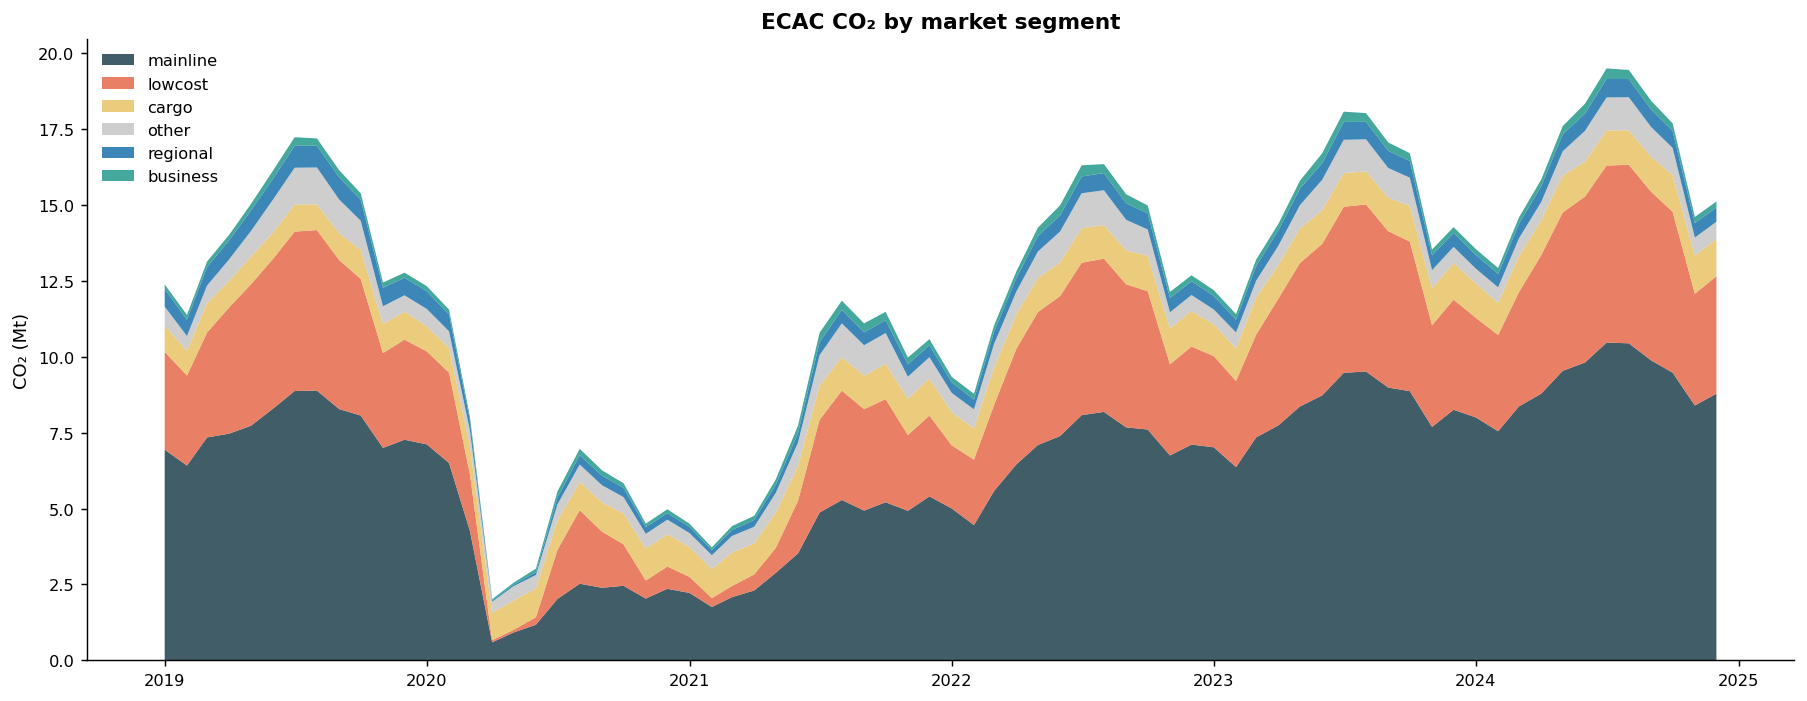

In [49]:
seg = (
    df_net[df_net["AREA"] == "ECAC"]
    .groupby(["DATE", "MARKET_SEGMENT"])["CO2_KG"]
    .sum()
    .reset_index()
)
seg_piv = seg.pivot(index="DATE", columns="MARKET_SEGMENT", values="CO2_KG").fillna(0) / 1e9
order = seg_piv.sum().sort_values(ascending=False).index

SEG_COLORS = {
    "mainline": SLATE,
    "lowcost":  ORANGE,
    "business": TEAL,
    "cargo":    YELLOW,
    "regional": BLUE,
    "other":    GRAY,
}

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.stackplot(
    seg_piv.index,
    *[seg_piv[c] for c in order],
    labels=list(order),
    colors=[SEG_COLORS.get(c, GRAY) for c in order],
    alpha=0.88,
)
ax.set_ylabel("CO\u2082 (Mt)")
ax.set_title("ECAC CO\u2082 by market segment")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

### 3.4 CO\u2082 by Flight Phase

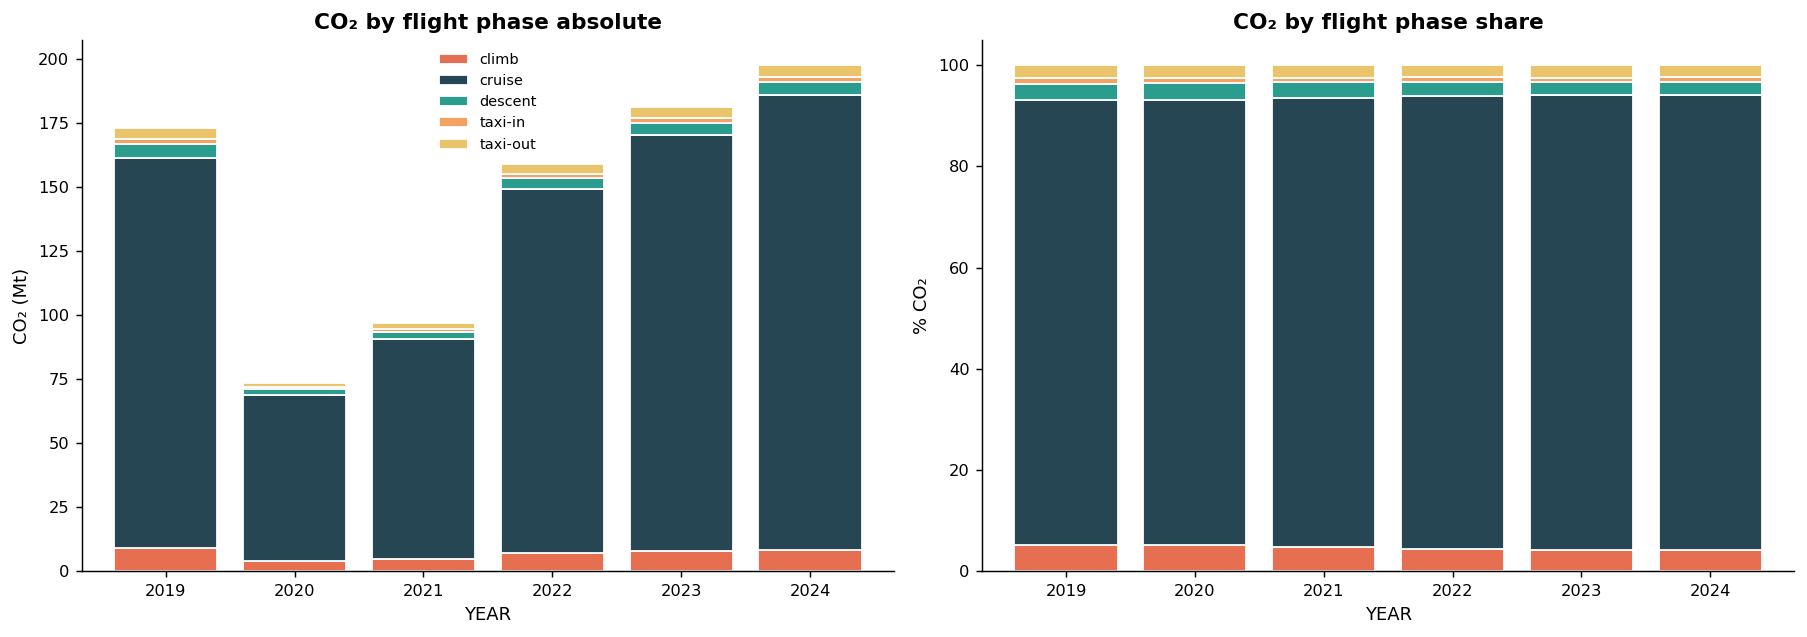

In [57]:
phase = (
    df_net[df_net["AREA"] == "ECAC"]
    .groupby(["YEAR", "FLIGHT_PHASE"])["CO2_KG"]
    .sum()
    .reset_index()
)
phase_piv = phase.pivot(index="YEAR", columns="FLIGHT_PHASE", values="CO2_KG") / 1e9
phase_pct = phase_piv.div(phase_piv.sum(axis=1), axis=0) * 100

PHASE_COLORS = {
    "cruise":   SLATE,
    "climb":    ORANGE,
    "descent":  TEAL,
    "taxi-out": YELLOW,
    "taxi-in":  "#F4A261",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

phase_piv.plot(kind="bar", stacked=True, ax=axes[0],
               color=[PHASE_COLORS.get(c, GRAY) for c in phase_piv.columns],
               edgecolor="white", width=0.8, legend=True)
axes[0].set_ylabel("CO\u2082 (Mt)")
axes[0].set_title("CO\u2082 by flight phase absolute")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=8)

phase_pct.plot(kind="bar", stacked=True, ax=axes[1],
               color=[PHASE_COLORS.get(c, GRAY) for c in phase_pct.columns],
               edgecolor="white", width=0.8, legend=False)
axes[1].set_ylabel("% CO\u2082")
axes[1].set_title("CO\u2082 by flight phase share")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 3.5 Flights & CO\u2082 by Flight Type

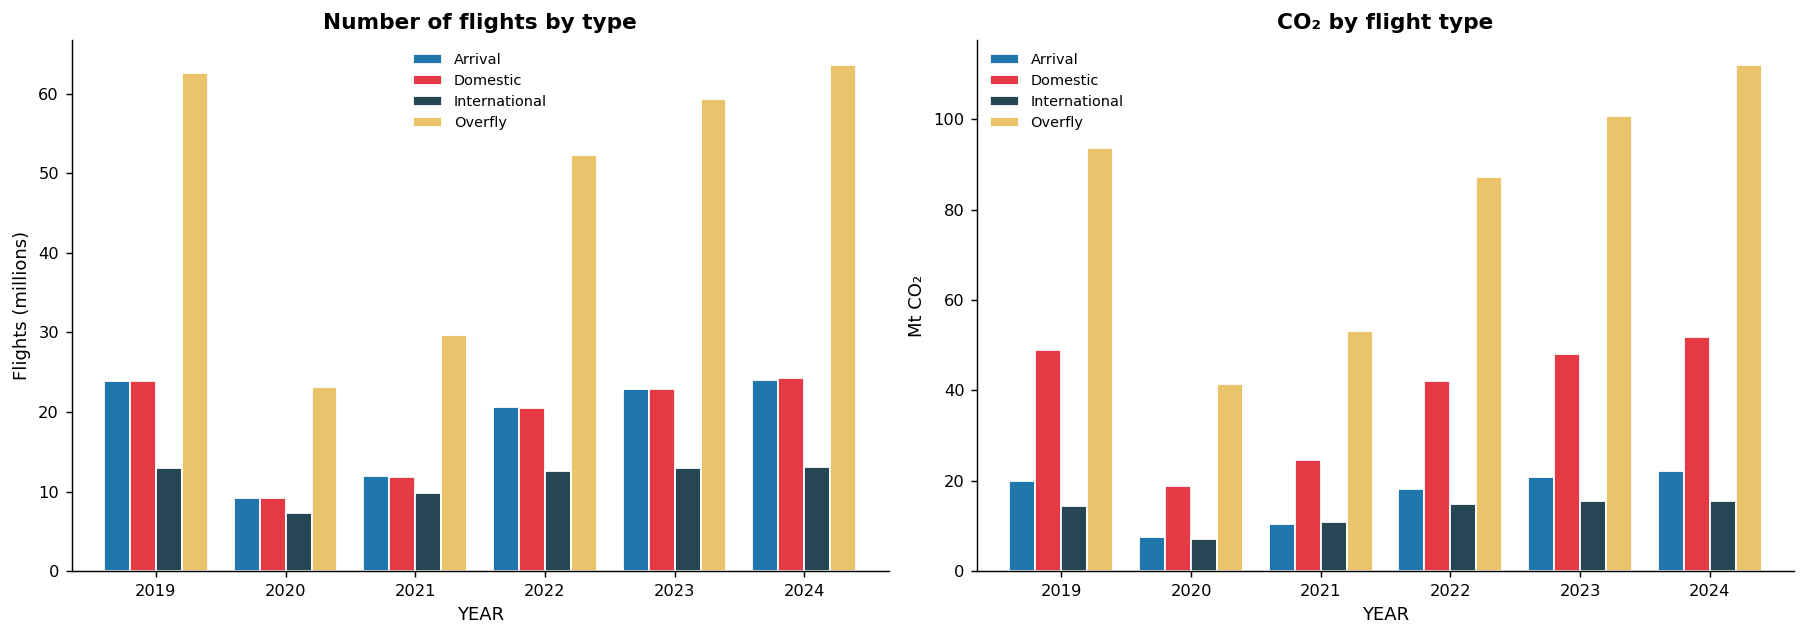

In [51]:
FT_LABELS  = {"D": "Domestic", "A": "Arrival", "I": "International", "O": "Overfly"}
FT_COLORS  = {"Domestic": RED, "Arrival": BLUE, "International": SLATE, "Overfly": YELLOW}

ft = df_state.groupby(["YEAR", "FLIGHT_TYPE"])[["CO2_KG", "NB_FLIGHTS"]].sum().reset_index()
ft["label"] = ft["FLIGHT_TYPE"].map(FT_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, ylabel, title in [
    (axes[0], "NB_FLIGHTS", "Flights (millions)",  "Number of flights by type"),
    (axes[1], "CO2_KG",     "Mt CO\u2082",           "CO\u2082 by flight type"),
]:
    piv      = ft.pivot(index="YEAR", columns="label", values=metric)
    divisor  = 1e9 if metric == "CO2_KG" else 1e6
    (piv / divisor).plot(
        kind="bar", ax=ax,
        color=[FT_COLORS[c] for c in piv.columns],
        edgecolor="white", width=0.8,
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.6 Top 25 States by Total CO\u2082

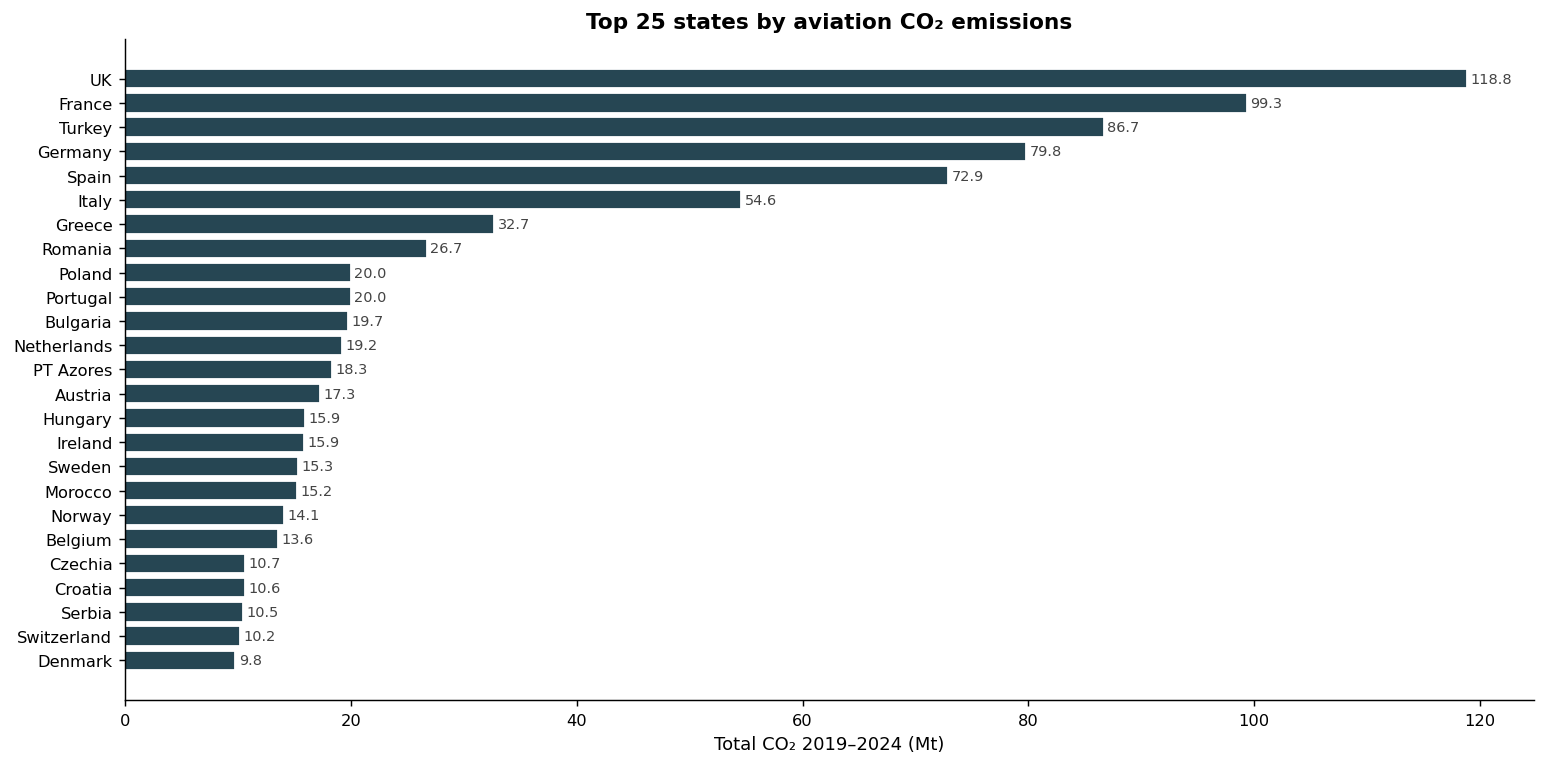

In [52]:
state_tot = (
    df_state.groupby("AREA")["CO2_KG"]
    .sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_tot["name"], state_tot["CO2_KG"] / 1e9, color=SLATE, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Total CO\u2082 2019\u20132024 (Mt)")
ax.set_title("Top 25 states by aviation CO\u2082 emissions")

for bar, val in zip(bars, state_tot["CO2_KG"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val / 1e9:.1f}", va="center", fontsize=8, color="#444")

plt.tight_layout()
plt.show()

### 3.8 CO\u2082 Efficiency per Flight

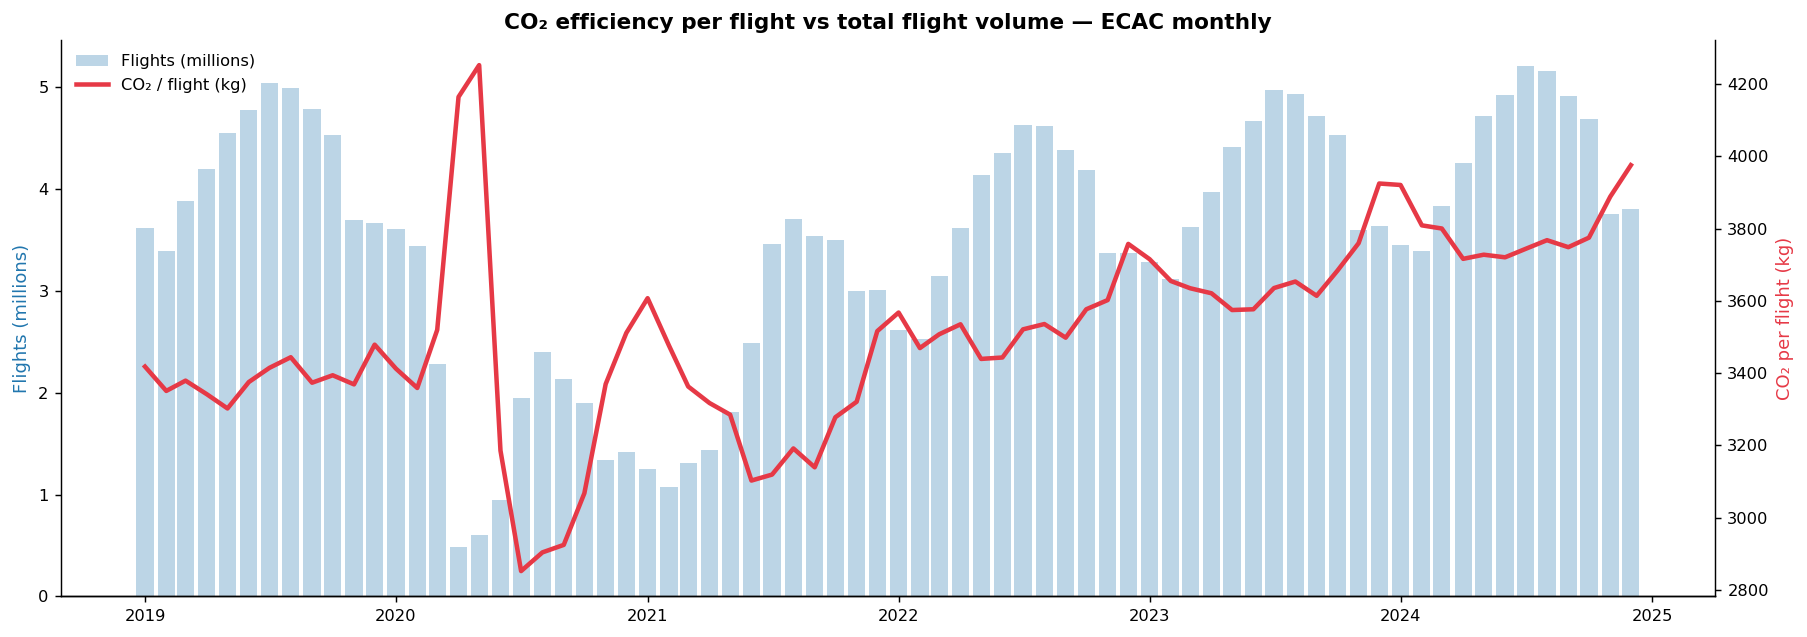

In [54]:
ecac_eff = ecac.groupby("DATE")[["CO2_KG", "NB_FLIGHTS"]].sum().reset_index()
ecac_eff["co2_per_flight_kg"] = ecac_eff["CO2_KG"] / ecac_eff["NB_FLIGHTS"]
ecac_eff = ecac_eff.sort_values("DATE")

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax2.spines["right"].set_visible(True)
ax2.spines["left"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax1.bar(ecac_eff["DATE"], ecac_eff["NB_FLIGHTS"] / 1e6,
        width=25, color=BLUE, alpha=0.3, label="Flights (millions)")
ax2.plot(ecac_eff["DATE"], ecac_eff["co2_per_flight_kg"],
         color=RED, lw=2.5, label="CO\u2082 / flight (kg)")

ax1.set_ylabel("Flights (millions)", color=BLUE)
ax2.set_ylabel("CO\u2082 per flight (kg)", color=RED)
ax1.set_title("CO\u2082 efficiency per flight vs total flight volume \u2014 ECAC monthly")

lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()